# 2. Signal Filtering Using Savitzky-Golay

Steps:
1. Load the cleaned dataframe.
2. Justify the choice of Savitzky-Golay (vs. Butterworth, MA).
3. Select the polynomial order N and the window length.
4. Verify the actual cutoff frequency (frequency response).
5. Apply the filter to each participant.
6. Save the filtered signals as a CSV file.

## 2.1 Imports et configuration

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, savgol_coeffs, freqz

PROJECT_DIR = Path.cwd().parent.parent

from config import (
    DATA_DIR, COORD_COLS, ID_COLS,
    FPS, SG_POLYORDER, SG_WINDOW_LENGTH,
)

print(f"FPS              : {FPS}")
print(f"SG_POLYORDER     : {SG_POLYORDER}")
print(f"SG_WINDOW_LENGTH : {SG_WINDOW_LENGTH}")

FPS              : 30.0
SG_POLYORDER     : 4
SG_WINDOW_LENGTH : 11


## 2.2 Loading the Cleaned Signals

Input: `data/movement/01_clean_signals.csv` generated by
Notebook 1.

In [2]:
in_path = DATA_DIR / "movement" / "01_clean_signals.csv"
df_signals_wide = pd.read_csv(in_path)

print(f"Loaded {in_path}")
print(f"Shape : {df_signals_wide.shape}")
display(df_signals_wide.head())

Loaded C:\Users\factory\Desktop\pons.lea\data\movement\01_clean_signals.csv
Shape : (36238, 13)


,group,participant_id,frame,left_shoulder_x,left_wrist_x,nose_x,right_shoulder_x,right_wrist_x,left_shoulder_y,left_wrist_y,nose_y,right_shoulder_y,right_wrist_y
0,P,P1,0,0.551109,0.513249,0.494273,0.437366,0.451267,0.764519,0.506094,0.884955,0.771039,0.499536
1,P,P1,1,0.551934,0.513923,0.495771,0.437479,0.451267,0.764174,0.505475,0.885404,0.770886,0.499538
2,P,P1,2,0.553424,0.514413,0.496511,0.438607,0.451295,0.764080,0.504557,0.885955,0.771016,0.500116
3,P,P1,3,0.555237,0.514497,0.498662,0.440048,0.451630,0.763992,0.504500,0.886327,0.771771,0.500956
4,P,P1,4,0.556226,0.514459,0.500877,0.441361,0.451765,0.764004,0.504875,0.887334,0.773063,0.502561


## 2.3 Choosing the Order of the Polynomial N

Crenna et al. (IMEKO 2015) recommend **N = 4** by default in
biomechanics: a fourth-degree polynomial captures the curvatures and
inflexions of the joint trajectories within the window, without
tracking the noise. A lower order (N=2) smooths too much; a higher
order (N≥6) begins to pick up noise.

We therefore keep **N = 4** and adjust only the length of
the window.

## 2.4 Selecting the Window Length by Scanning the Actual Cutoff

We **directly measure**
the frequency response using `scipy.signal.freqz` for several
window lengths and choose the one whose -3 dB cutoff
is closest to our target (≈ 5 Hz, below which
slow body movements occur, and above which we
consider it to be MediaPipe noise).

In [3]:
def measure_savgol_cutoff(window_length, polyorder, fps):
    """
    Measures the -3 dB cutoff of an SG filter by analyzing its
    frequency response. Also returns the attenuation at a few
    key frequencies.
    """
    h = savgol_coeffs(window_length, polyorder, deriv=0)
    w, H = freqz(h, worN=8192, fs=fps)
    mag_db = 20 * np.log10(np.abs(H) + 1e-12)

    below_3db = np.where(mag_db <= -3.0)[0]
    fc = w[below_3db[0]] if len(below_3db) else np.nan

    return {
        "window": window_length,
        "M": (window_length - 1) // 2,
        "f_c (Hz)": fc,
        "att @5Hz (dB)": mag_db[np.argmin(np.abs(w - 5.0))],
        "att @7.5Hz (dB)": mag_db[np.argmin(np.abs(w - 7.5))],
        "att @10Hz (dB)": mag_db[np.argmin(np.abs(w - 10.0))],
    }


# Scanning plausible odd-numbered windows.
candidate_windows = [7, 9, 11, 13, 15, 17]
summary = pd.DataFrame([
    measure_savgol_cutoff(w, SG_POLYORDER, FPS) for w in candidate_windows
])
display(summary.round(2))

,window,M,f_c (Hz),att @5Hz (dB),att @7.5Hz (dB),att @10Hz (dB)
0,7,3,8.42,-0.19,-1.65,-7.62
1,9,4,6.10,-1.08,-9.19,-11.75
2,11,5,4.85,-3.52,-16.13,-23.09
3,13,6,4.04,-9.40,-12.25,-14.46
4,15,7,3.47,-48.12,-30.05,-21.67
5,17,8,3.05,-12.96,-15.04,-22.62


**Interpreting the table** (at FPS = 30 Hz, N = 4):

- window = 7 → cutoff ≈ 8.4 Hz: too loose, lets noise through.
- window = 9 → cutoff ≈ 6.1 Hz: still a little too loose.
- **window = 11 → cutoff ≈ 4.9 Hz: closest to the 5 Hz target.**
- window = 13 → cutoff ≈ 4.0 Hz: a little too strict.
- window ≥ 15 → cutoff < 3.5 Hz: we begin to attenuate
  actual rapid body movements.

We therefore choose **window_length = 11** (= 2M+1 with M=5,
i.e., ≈ 0.37 s at 30 fps), a value stored in `config.py` as
`SG_WINDOW_LENGTH`.

**Same window length as in Vattier et al., 2026.**

## 2.5 Applying the Filter

For each participant, we filter each column of coordinates
independently using `scipy.signal.savgol_filter`. NaN values are
temporarily replaced by the mean of the series during
filtering (otherwise SG would propagate them), then restored
as-is after filtering.

In [4]:
def filter_series_savgol(series, window_length, polyorder):
    """
    Apply a Savitzky-Golay filter (smoothing mode, deriv=0) to a 1D series.

    If the series contains NaN values or is too short, it is returned
    unchanged (unfiltered). NaN values are not modified.

    Returns
    -------
    filtered : pd.Series
        Filtered series, or unchanged if filtering cannot be applied.
    was_filtered : bool
        True if filtering was successfully applied.
    """
    values = series.to_numpy(dtype=float)

    if len(values) < window_length:
        return pd.Series(values, index=series.index), False
    if np.isnan(values).any():
        return pd.Series(values, index=series.index), False

    filtered = savgol_filter(
        values,
        window_length=window_length,
        polyorder=polyorder,
        deriv=0,
        mode="interp",
    )

    return pd.Series(filtered, index=series.index), True


def filter_coordinate_signals(df_wide, window_length, polyorder,
                              coord_cols=COORD_COLS):
    """
    Apply the Savitzky-Golay filter to all coordinate columns,
    separately for each participant.

    Signals containing NaN values are not filtered and remain unchanged.
    The function also returns a DataFrame listing all unfiltered
    (participant, signal) pairs.
    """
    df = df_wide.copy()

    missing = [c for c in coord_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    skipped_rows = []

    for pid, sub in df.groupby("participant_id", sort=False):
        for col in coord_cols:
            series = sub[col]

            filtered_series, was_filtered = filter_series_savgol(
                series,
                window_length,
                polyorder,
            )

            df.loc[sub.index, col] = filtered_series.values

            if not was_filtered:
                reason = (
                    "all_nan" if series.isna().all()
                    else "contains_nan" if series.isna().any()
                    else "too_short"
                )

                skipped_rows.append({
                    "participant_id": pid,
                    "signal": col,
                    "reason": reason,
                    "n_nan": int(series.isna().sum()),
                    "n_total": len(series),
                })

    skipped_df = pd.DataFrame(skipped_rows)

    return df, skipped_df


df_signals_filtered, skipped = filter_coordinate_signals(
    df_signals_wide,
    window_length=SG_WINDOW_LENGTH,
    polyorder=SG_POLYORDER,
)

print("Savitzky-Golay filtering completed.")
print(f"Unfiltered signals: {len(skipped)}")

if not skipped.empty:
    print("\nDetails of unfiltered signals (NaN values or signals too short):")
    display(skipped)
else:
    print("All signals were successfully filtered.")

display(df_signals_filtered[ID_COLS + COORD_COLS].head())

Savitzky-Golay filtering completed.
Unfiltered signals: 4

Details of unfiltered signals (NaN values or signals too short):


,participant_id,signal,reason,n_nan,n_total
0,SZ4,left_wrist_x,all_nan,913,913
1,SZ4,left_wrist_y,all_nan,913,913
2,SZ4,right_wrist_x,all_nan,913,913
3,SZ4,right_wrist_y,all_nan,913,913


,group,participant_id,frame,nose_x,nose_y,left_shoulder_x,left_shoulder_y,right_shoulder_x,right_shoulder_y,left_wrist_x,left_wrist_y,right_wrist_x,right_wrist_y
0,P,P1,0,0.494323,0.885001,0.550992,0.764520,0.437280,0.771066,0.513236,0.506139,0.451252,0.499538
1,P,P1,1,0.495482,0.885384,0.552154,0.764196,0.437653,0.770782,0.513973,0.505323,0.451268,0.499531
2,P,P1,2,0.496994,0.885796,0.553548,0.764030,0.438644,0.771114,0.514354,0.504723,0.451389,0.500096
3,P,P1,3,0.498642,0.886402,0.554926,0.763986,0.439921,0.771870,0.514497,0.504498,0.451550,0.501086
4,P,P1,4,0.500249,0.887284,0.556109,0.764020,0.441226,0.772876,0.514495,0.504713,0.451699,0.502355


## 2.6 Visual Inspection

A raw signal is compared to its filtered equivalent for a participant.
The filter must smooth out high-frequency noise without attenuating the
peaks (a key property of the Savitzky-Golay filter).

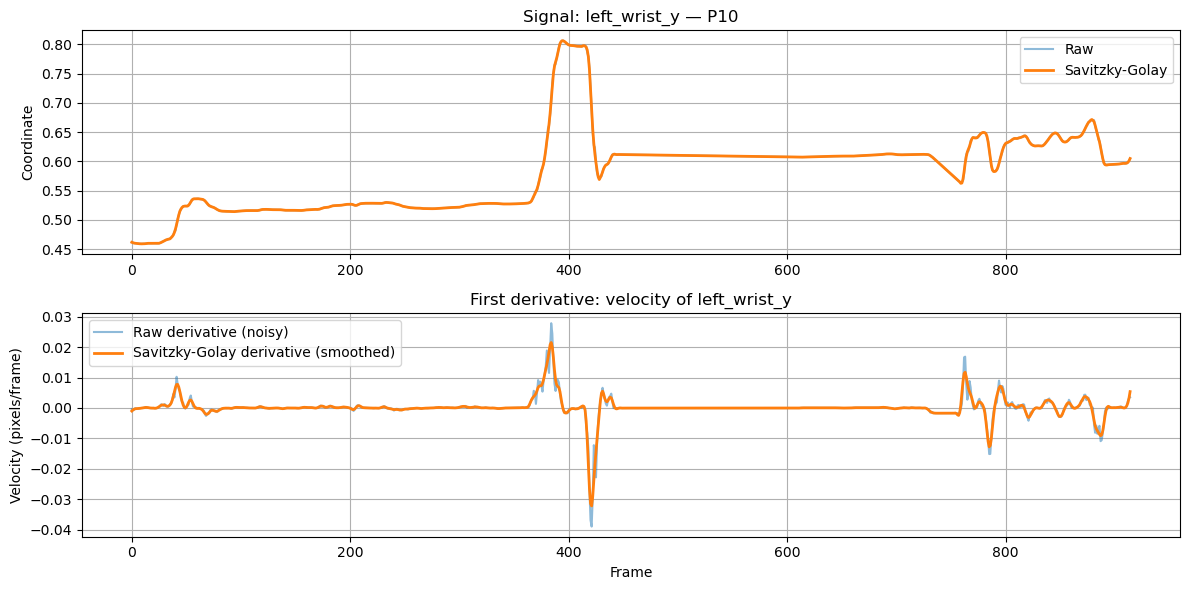

In [5]:
TEST_PID = "P10"
COL = "left_wrist_y"

raw = df_signals_wide.loc[
    df_signals_wide["participant_id"] == TEST_PID, ["frame", COL]
]

filt = df_signals_filtered.loc[
    df_signals_filtered["participant_id"] == TEST_PID, ["frame", COL]
]

# Compute derivatives (raw and filtered)
raw_deriv = np.gradient(raw[COL].values, 1)  # Raw numerical derivative

filt_deriv = savgol_filter(
    filt[COL].values,
    window_length=SG_WINDOW_LENGTH,
    polyorder=SG_POLYORDER,
    deriv=1,
    mode="interp",
)

# Two plots: signal and derivative
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

# Signal
ax1.plot(raw["frame"], raw[COL], label="Raw", alpha=0.5)
ax1.plot(
    filt["frame"],
    filt[COL],
    label="Savitzky-Golay",
    linewidth=2,
)

ax1.set_title(f"Signal: {COL} — {TEST_PID}")
ax1.set_ylabel("Coordinate")
ax1.legend()
ax1.grid(True)

# First derivative (velocity)
ax2.plot(
    raw["frame"],
    raw_deriv,
    label="Raw derivative (noisy)",
    alpha=0.5,
)

ax2.plot(
    filt["frame"],
    filt_deriv,
    label="Savitzky-Golay derivative (smoothed)",
    linewidth=2,
)

ax2.set_title(f"First derivative: velocity of {COL}")
ax2.set_xlabel("Frame")
ax2.set_ylabel("Velocity (pixels/frame)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## 2.7 Saving the Filtered Signals

Output: `data/movement/02_filtered_signals.csv`. This file
will be the input for Notebook 3 (calculation of movements).

In [6]:
out_path = DATA_DIR / "movement" / "02_filtered_signals.csv"
df_signals_filtered.to_csv(out_path, index=False)

print(f"Saved filtered signals -> {out_path}")
display(df_signals_filtered.head())

Saved filtered signals -> C:\Users\factory\Desktop\pons.lea\data\movement\02_filtered_signals.csv


,group,participant_id,frame,left_shoulder_x,left_wrist_x,nose_x,right_shoulder_x,right_wrist_x,left_shoulder_y,left_wrist_y,nose_y,right_shoulder_y,right_wrist_y
0,P,P1,0,0.550992,0.513236,0.494323,0.437280,0.451252,0.764520,0.506139,0.885001,0.771066,0.499538
1,P,P1,1,0.552154,0.513973,0.495482,0.437653,0.451268,0.764196,0.505323,0.885384,0.770782,0.499531
2,P,P1,2,0.553548,0.514354,0.496994,0.438644,0.451389,0.764030,0.504723,0.885796,0.771114,0.500096
3,P,P1,3,0.554926,0.514497,0.498642,0.439921,0.451550,0.763986,0.504498,0.886402,0.771870,0.501086
4,P,P1,4,0.556109,0.514495,0.500249,0.441226,0.451699,0.764020,0.504713,0.887284,0.772876,0.502355
